# Simulated EEG multiverse

We first define the forking paths:

In [1]:
from comet.multiverse import Multiverse

forking_paths = {
    "software": ["MNE", "FieldTrip", "EEGLab"],
    "resampling": [250, 500, 512],
    "stimulation": ["IAF", "9", "10", "11"],
    "electrode": ["Pz", "O1", "O2", "P3", "P4"],
}

The template script then creates systematically varying artificial data by adding some "signal" + noise to a baseline value :

In [2]:
def analysis_template():
    import comet
    import numpy as np

    base_value = 10
    if {{software}} == "EEGLab":
        base_value += 2
    if {{stimulation}} == "IAF":
        base_value += 5
    if {{electrode}} == "Pz":
        base_value += 7
    if {{stimulation}} == "IAF" and {{electrode}} == "Pz":
        base_value += 2

    # Generate 50 outcome values (mock differences in alpha power)
    power_diffs = [base_value + np.random.normal(0, 35) for _ in range(50)]

    result = {
        "power_diffs": [round(power_diff, 3) for power_diff in power_diffs],
    }

    comet.utils.save_universe_results(result)

You can then create and visualize the multiverse:

,Universe,Decision 1,Value 1,Decision 2,Value 2,Decision 3,Value 3,Decision 4,Value 4
0,Universe_1,software,MNE,resampling,250,stimulation,IAF,electrode,Pz
1,Universe_2,software,MNE,resampling,250,stimulation,IAF,electrode,O1
2,Universe_3,software,MNE,resampling,250,stimulation,IAF,electrode,O2
3,Universe_4,software,MNE,resampling,250,stimulation,IAF,electrode,P3
4,Universe_5,software,MNE,resampling,250,stimulation,IAF,electrode,P4
...,...,...,...,...,...,...,...,...,...
175,Universe_176,software,EEGLab,resampling,512,stimulation,11,electrode,Pz
176,Universe_177,software,EEGLab,resampling,512,stimulation,11,electrode,O1
177,Universe_178,software,EEGLab,resampling,512,stimulation,11,electrode,O2
178,Universe_179,software,EEGLab,resampling,512,stimulation,11,electrode,P3


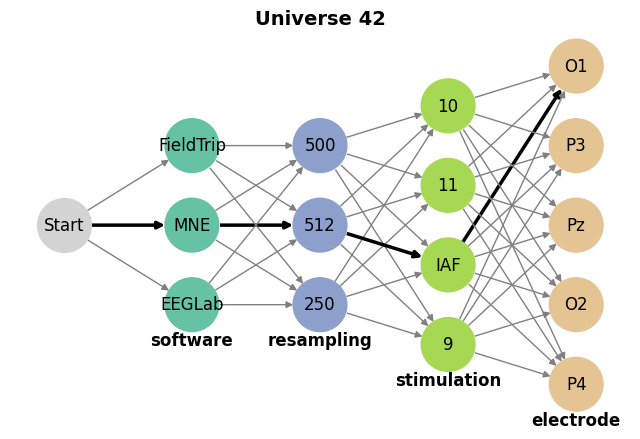

In [3]:
mverse = Multiverse(name="example_mv_eeg_sim")
mverse.create(analysis_template, forking_paths)
mverse.summary()
mverse.visualize(universe=42)

And subsequently run it:

In [4]:
#mverse.run(parallel=8)

Once completed, the results can be visualised in a specification curve:

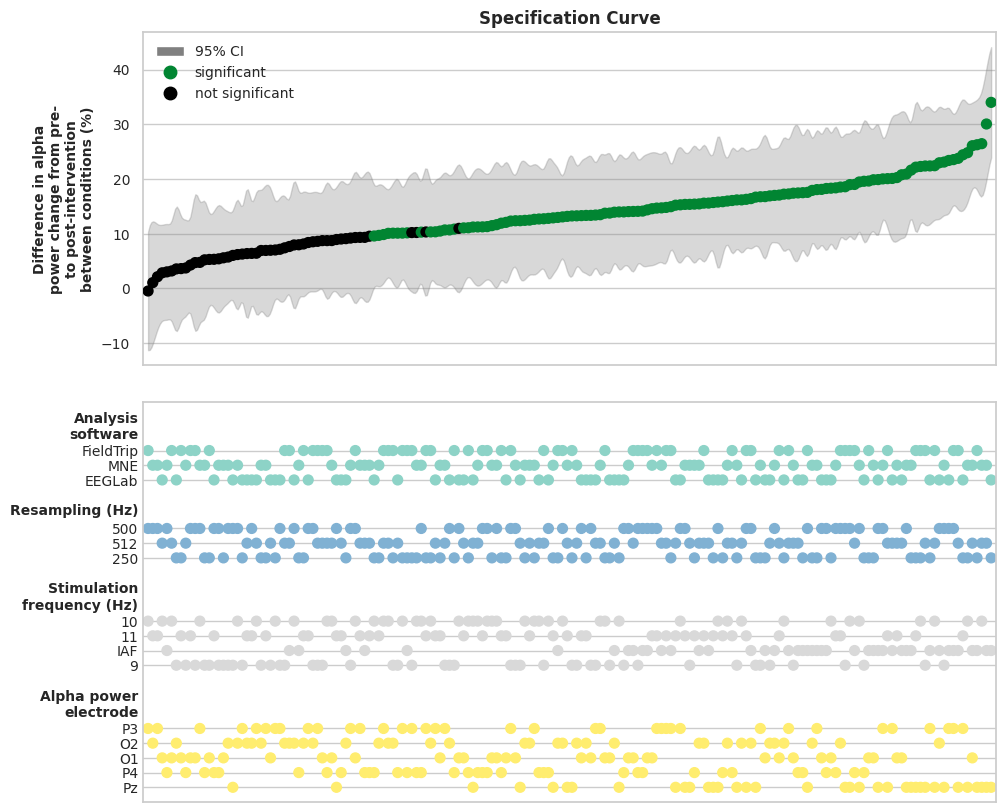

In [ ]:
# Custom labels for the specification curve can be provided as a dict
name_map = {
    "power_diffs": "Difference in alpha\npower change from pre-\nto post-intervention\nbetween conditions (%)",
    "software": "Analysis\nsoftware",
    "stimulation": "Stimulation\nfrequency (Hz)",
    "electrode": "Alpha power\nelectrode",
    "resampling": "Resampling (Hz)"
}
mverse.specification_curve(measure="power_diffs", name_map=name_map, p_value=0.05, ci=95, smooth_ci=True, \
                               cmap="Set3", figsize=(11,10), fontsize=10, height_ratio=[1,1.2], ftype="pdf")

You can access the results from the multiverse analysis for either all universes, or for a single universe:

In [ ]:
# Get results for all universes as a nested dict
results = mverse.get_results()
print("Universe 1 results:", results["universe_1"]["power_diffs"])

# Get results for a specific universe
results = mverse.get_results(universe=1)
print("Universe 1 results:", results["power_diffs"])

# Get all results as a pandas DataFrame
results = mverse.get_results(as_df=True)
results

Universe 1 results: [67.014, 5.703, -49.709, 11.119, 45.936, 19.034, 7.951, -29.429, 54.81, -21.862, -15.898, 63.534, 29.297, -35.323, 82.95, 42.957, 30.907, 63.272, 16.411, 32.871, 12.588, 40.848, 46.304, 24.427, 50.794, 20.116, 36.156, 14.538, -3.696, 29.784, 55.557, 31.163, 30.315, -9.504, -9.879, 65.068, -34.048, 46.998, 32.856, 28.72, 28.919, -59.095, -13.454, 46.125, 4.363, 35.157, 29.446, 42.173, 21.842, 14.754]
Universe 1 results: [67.014, 5.703, -49.709, 11.119, 45.936, 19.034, 7.951, -29.429, 54.81, -21.862, -15.898, 63.534, 29.297, -35.323, 82.95, 42.957, 30.907, 63.272, 16.411, 32.871, 12.588, 40.848, 46.304, 24.427, 50.794, 20.116, 36.156, 14.538, -3.696, 29.784, 55.557, 31.163, 30.315, -9.504, -9.879, 65.068, -34.048, 46.998, 32.856, 28.72, 28.919, -59.095, -13.454, 46.125, 4.363, 35.157, 29.446, 42.173, 21.842, 14.754]


,universe,power_diffs,__decisions
1,universe_1,"[67.014, 5.703, -49.709, 11.119, 45.936, 19.03...","{'Decision 1': 'software', 'Value 1': 'MNE', '..."
2,universe_2,"[28.819, -11.62, 28.109, -3.907, -71.454, 13.5...","{'Decision 1': 'software', 'Value 1': 'MNE', '..."
3,universe_3,"[0.553, 13.525, 61.945, 24.676, -8.701, 44.238...","{'Decision 1': 'software', 'Value 1': 'MNE', '..."
4,universe_4,"[-21.138, -8.721, -2.282, 53.482, 9.061, 25.69...","{'Decision 1': 'software', 'Value 1': 'MNE', '..."
5,universe_5,"[-59.789, 42.714, 45.28, 11.62, 48.159, 23.48,...","{'Decision 1': 'software', 'Value 1': 'MNE', '..."
...,...,...,...
176,universe_176,"[41.824, -4.568, 8.542, -15.285, 20.938, 30.59...","{'Decision 1': 'software', 'Value 1': 'EEGLab'..."
177,universe_177,"[38.502, -42.331, 15.3, 2.637, 30.061, -4.535,...","{'Decision 1': 'software', 'Value 1': 'EEGLab'..."
178,universe_178,"[73.157, 14.318, 35.587, 59.257, -3.919, 9.886...","{'Decision 1': 'software', 'Value 1': 'EEGLab'..."
179,universe_179,"[10.067, 0.806, 45.277, -2.37, 17.171, 5.593, ...","{'Decision 1': 'software', 'Value 1': 'EEGLab'..."
